# Real-data tutorial 1: subQ Rab8a spatial state

**Dataset:** five-section MC38-Cas9 subcutaneous SPAC-seq cohort.

**Best-supported dataset-level conclusion:** the eight evaluable
`sgRab8a_1` source clones across subQ-2, subQ-4 and subQ-5 are
surrounded by a more hypoxic, IFN-low, malignant-like spatial
state. This is a reproducible association, but it is **not** a
formal propagation-radius estimate: only one Rab8a guide is
represented, mouse identities are unavailable, and niche selection
cannot be separated from active remodelling.

This notebook uses frozen candidate-level derivatives from the full
real-data analysis. It does not load the multi-gigabyte RNA matrix.

## 1. Load the frozen real-data tables

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import perturbradius as pr

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("tutorials/data")
if not DATA_DIR.exists():
    raise FileNotFoundError("Run from the repository root or tutorials directory")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {
    "orange": "#D55E00",
    "blue": "#0072B2",
    "green": "#009E73",
    "purple": "#CC79A7",
    "gray": "#777777",
}
print("PerturbRadius", pr.__version__)

PerturbRadius 0.1.0


In [2]:
locations = pd.read_csv(DATA_DIR / "subq_rab8a_clone_locations.tsv", sep="\t")
clone_effects = pd.read_csv(DATA_DIR / "subq_rab8a_component_near_far.tsv", sep="\t")
section_effects = pd.read_csv(DATA_DIR / "subq_rab8a_section_near_far.tsv", sep="\t")
rings = pd.read_csv(DATA_DIR / "subq_rab8a_rings.tsv", sep="\t")
coverage = pd.read_csv(DATA_DIR / "subq_rab8a_coverage.tsv", sep="\t")
cohort_summary = pd.read_csv(DATA_DIR / "subq_cross_cohort_gene_summary.tsv", sep="\t")
robustness = pd.read_csv(DATA_DIR / "subq_cross_cohort_robustness.tsv", sep="\t")

data_summary = pd.DataFrame({
    "quantity": [
        "all detected Rab8a components",
        "ring-complete evaluable clones",
        "evaluable sections",
        "independent Rab8a guides",
        "physical bin size",
    ],
    "value": [
        int(coverage.loc[0, "clones"]),
        clone_effects["clone_id"].nunique(),
        clone_effects["section"].nunique(),
        int(coverage.loc[0, "guides"]),
        "8 µm",
    ],
})
display(data_summary)

,quantity,value
0,all detected Rab8a components,43
1,ring-complete evaluable clones,8
2,evaluable sections,3
3,independent Rab8a guides,1
4,physical bin size,8 µm


The full screen contains 43 Rab8a-labelled components across five
sections, but only eight clones have complete, interpretable rings
for this malignant-state comparison. Restricting to complete
neighbourhoods avoids treating tissue-edge truncation as a
biological distance effect.

## 2. Spatial distribution of the eight evaluable clones

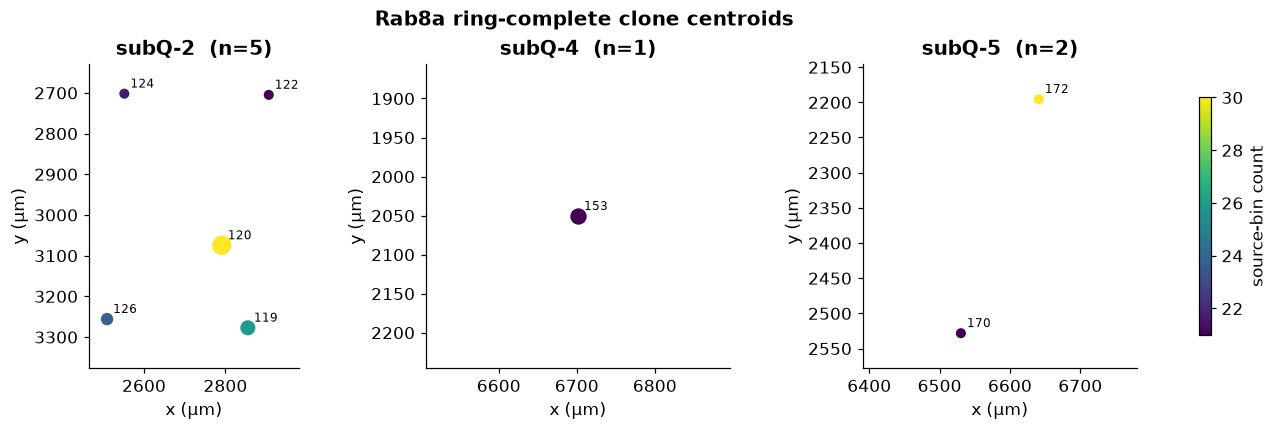

In [3]:
sections = ["subQ-2", "subQ-4", "subQ-5"]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
for ax, section in zip(axes, sections):
    rows = locations.loc[locations["section"].eq(section)].copy()
    sizes = np.clip(rows["source_bin_count"] * 1.6, 55, 240)
    scatter = ax.scatter(
        rows["centroid_x_um"], rows["centroid_y_um"],
        s=sizes, c=rows["source_bin_count"], cmap="viridis",
        edgecolor="white", linewidth=0.8,
    )
    for row in rows.itertuples():
        ax.annotate(row.clone_id[-3:], (row.centroid_x_um, row.centroid_y_um),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    x_center, y_center = rows["centroid_x_um"].mean(), rows["centroid_y_um"].mean()
    x_span = max(rows["centroid_x_um"].max() - rows["centroid_x_um"].min(), 300)
    y_span = max(rows["centroid_y_um"].max() - rows["centroid_y_um"].min(), 300)
    ax.set_xlim(x_center - 0.65 * x_span, x_center + 0.65 * x_span)
    ax.set_ylim(y_center - 0.65 * y_span, y_center + 0.65 * y_span)
    ax.set_title(f"{section}  (n={len(rows)})", fontweight="bold")
    ax.set(xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
    ax.invert_yaxis()
fig.colorbar(scatter, ax=axes, label="source-bin count", shrink=0.78)
fig.suptitle("Rab8a ring-complete clone centroids", fontweight="bold")
plt.show()

Marker area and colour encode source-bin count; labels are clone ID
suffixes. These are clone centroids, not full tissue maps, and
therefore serve as a replication/coverage audit rather than a
morphology analysis.

## 3. Clone-level near-versus-far effects

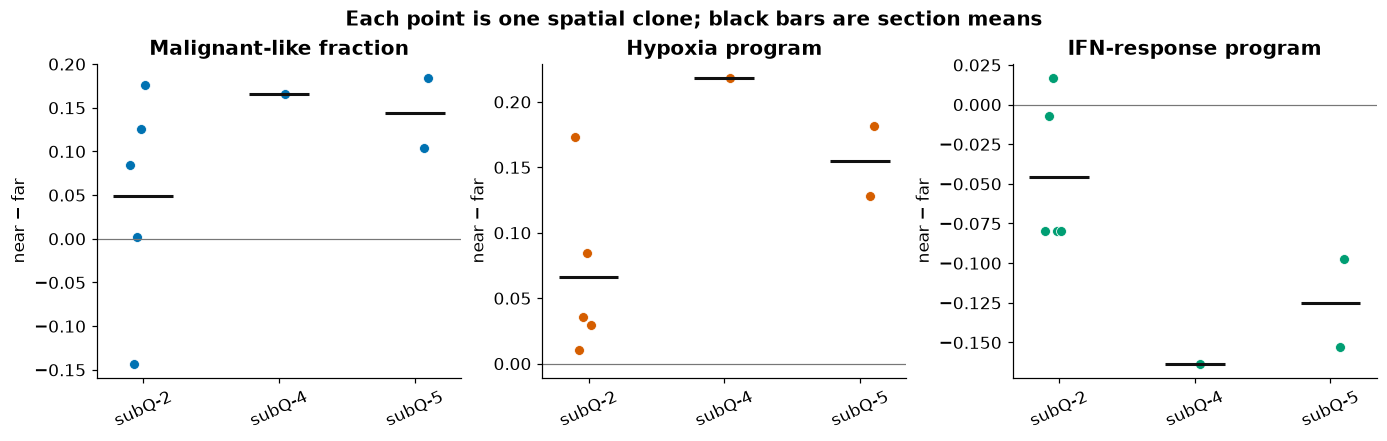

,response,mean near−far,direction-agreeing clones,sections
0,Hypoxia program,0.1075,8/8,3
1,IFN-response program,-0.0804,7/8,3
2,Malignant-like fraction,0.0874,7/8,3


In [4]:
response_order = [
    "Malignant-like fraction",
    "Hypoxia program",
    "IFN-response program",
]
response_colors = {
    "Malignant-like fraction": COLORS["blue"],
    "Hypoxia program": COLORS["orange"],
    "IFN-response program": COLORS["green"],
}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9), constrained_layout=True)
section_positions = {name: i for i, name in enumerate(sections)}
for ax, response in zip(axes, response_order):
    rows = clone_effects.loc[clone_effects["response"].eq(response)].copy()
    x = rows["section"].map(section_positions).to_numpy(dtype=float)
    jitter = np.linspace(-0.10, 0.10, len(rows))
    ax.scatter(x + jitter, rows["effect"], s=42, color=response_colors[response],
               edgecolor="white", linewidth=0.5)
    means = rows.groupby("section", observed=True)["effect"].mean()
    for section, value in means.items():
        ax.hlines(value, section_positions[section] - 0.22,
                  section_positions[section] + 0.22, color="#111111", linewidth=2)
    ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
    ax.set_xticks(range(len(sections)), sections, rotation=25)
    ax.set_title(response, fontweight="bold")
    ax.set_ylabel("near − far")
fig.suptitle("Each point is one spatial clone; black bars are section means",
             fontweight="bold")
plt.show()

expected_sign = {
    "Malignant-like fraction": 1,
    "Hypoxia program": 1,
    "IFN-response program": -1,
}
direction_summary = []
for response, rows in clone_effects.groupby("response", observed=True):
    agree = (rows["effect"] * expected_sign[response] > 0).sum()
    direction_summary.append({
        "response": response,
        "mean near−far": rows["effect"].mean(),
        "direction-agreeing clones": f"{agree}/{len(rows)}",
        "sections": rows["section"].nunique(),
    })
display(pd.DataFrame(direction_summary).round(4))

## 4. Empirical response versus distance from clone boundary

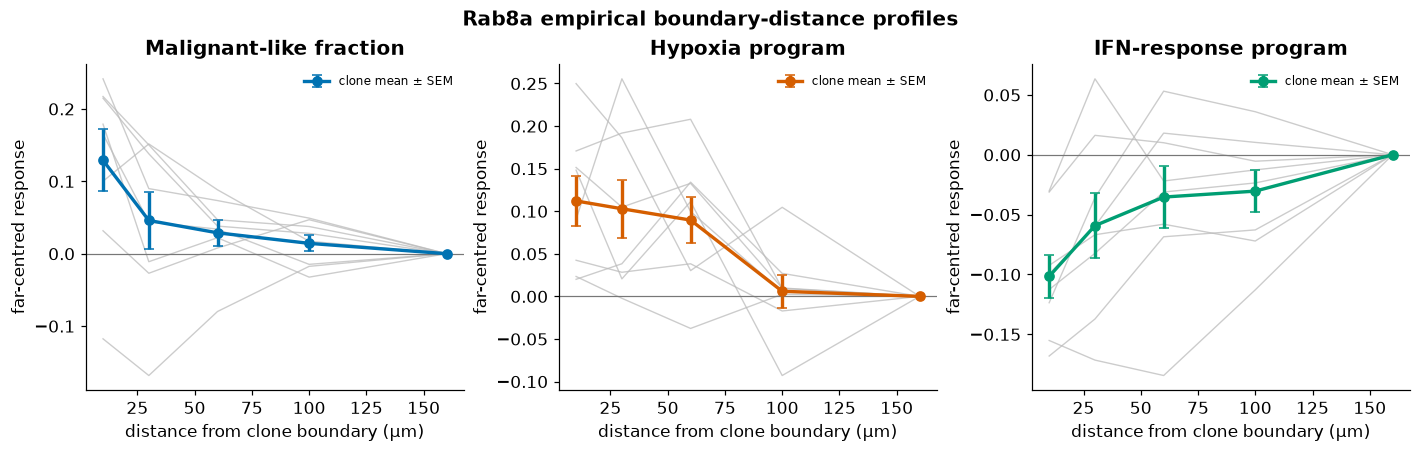

In [5]:
ring_mid = (rings["ring_start_um"] + rings["ring_end_um"]) / 2
rings = rings.assign(ring_midpoint_um=ring_mid)
response_columns = {
    "Malignant-like fraction": "malignant_fraction",
    "Hypoxia program": "malignant_hypoxia_score_mean",
    "IFN-response program": "malignant_ifn_response_score_mean",
}
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.0), constrained_layout=True)
curve_summaries = []
for ax, (label, column) in zip(axes, response_columns.items()):
    table = rings[["entity_id", "ring_id", "ring_midpoint_um", column]].copy()
    far = table.loc[table["ring_id"].eq(table["ring_id"].max())].set_index("entity_id")[column]
    table["far_centered"] = table[column] - table["entity_id"].map(far)
    for _, clone in table.groupby("entity_id", observed=True):
        ax.plot(clone["ring_midpoint_um"], clone["far_centered"],
                color="#BBBBBB", linewidth=0.9, alpha=0.75)
    summary = table.groupby("ring_midpoint_um", observed=True)["far_centered"].agg(["mean", "sem"]).reset_index()
    ax.errorbar(summary["ring_midpoint_um"], summary["mean"], yerr=summary["sem"],
                marker="o", linewidth=2.2, capsize=3,
                color=response_colors[label], label="clone mean ± SEM")
    ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
    ax.set(xlabel="distance from clone boundary (µm)", ylabel="far-centred response")
    ax.set_title(label, fontweight="bold")
    ax.legend(frameon=False, fontsize=8)
    summary.insert(0, "response", label)
    curve_summaries.append(summary)
fig.suptitle("Rab8a empirical boundary-distance profiles", fontweight="bold")
plt.show()

## 5. Cross-cohort direction check

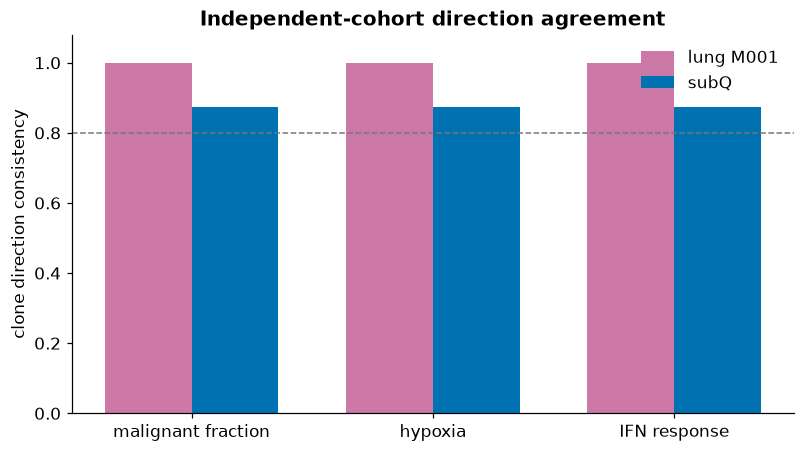

,label,lung_clones,subq_clones,concordant_clones_total,clones_total,exploratory_sign_fdr
16,malignant fraction,3,8,10,11,0.0371
17,hypoxia,3,8,10,11,0.0371
18,IFN response,3,8,10,11,0.0371


In [6]:
key = robustness.loc[
    robustness["target_gene"].eq("Rab8a")
    & robustness["target_cell_type"].eq("Malignant-like")
    & robustness["response"].isin(["cell_type_fraction", "hypoxia", "ifn_response"])
].copy()
label_map = {
    "cell_type_fraction": "malignant fraction",
    "hypoxia": "hypoxia",
    "ifn_response": "IFN response",
}
key["label"] = key["response"].map(label_map)
x = np.arange(len(key))
width = 0.36
fig, ax = plt.subplots(figsize=(7.2, 4.0), constrained_layout=True)
ax.bar(x - width/2, key["lung_direction_consistency"], width,
       color=COLORS["purple"], label="lung M001")
ax.bar(x + width/2, key["subq_direction_consistency"], width,
       color=COLORS["blue"], label="subQ")
ax.set_xticks(x, key["label"])
ax.set(ylim=(0, 1.08), ylabel="clone direction consistency")
ax.axhline(0.8, color=COLORS["gray"], linestyle="--", linewidth=1)
ax.legend(frameon=False)
ax.set_title("Independent-cohort direction agreement", fontweight="bold")
plt.show()
display(key[[
    "label", "lung_clones", "subq_clones", "concordant_clones_total",
    "clones_total", "exploratory_sign_fdr",
]].round(4))

## Conclusion

Rab8a-labelled clones reproducibly occupy or generate a locally
hypoxic, IFN-low, malignant-enriched state. The strongest
interpretation supported by these data is a **spatial
association** replicated across tumor sites. A causal propagation
radius is not reported because the same single guide
(`sgRab8a_1`) drives both cohorts, true mouse replication is
unavailable for subQ, and the curves do not distinguish niche
selection from active non-cell-autonomous remodelling.